# A/B Testing Profissional: Cookie Cats - Análise de Retenção

**Objetivo**: Avaliar o impacto de mover a primeira gate de nível 30 para nível 40 no jogo mobile *Cookie Cats*.

**Métricas principais**:
- Retenção em 1 dia (`retention_1`)
- Retenção em 7 dias (`retention_7`)
- Número de rodadas jogadas na primeira semana (`sum_gamerounds`)

**Grupo A (controle)**: gate no nível 30  
**Grupo B (teste)**: gate no nível 40

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, shapiro
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette('deep')

## 1. Carregamento e Exploração Inicial dos Dados

In [92]:
df = pd.read_csv('cookie_cats.csv')
print(f"Dimensão dos dados: {df.shape}")
df.head()

Dimensão dos dados: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [94]:
# Verificar balanceamento dos grupos
print(df['version'].value_counts())
print(f"\nProporção grupo A: {df['version'].value_counts()['gate_30']/len(df):.3f}")
print(f"Proporção grupo B: {df['version'].value_counts()['gate_40']/len(df):.3f}")

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

Proporção grupo A: 0.496
Proporção grupo B: 0.504


## 2. Tratamento de Outliers

A variável `sum_gamerounds` é altamente assimétrica e possui um outlier extremo.

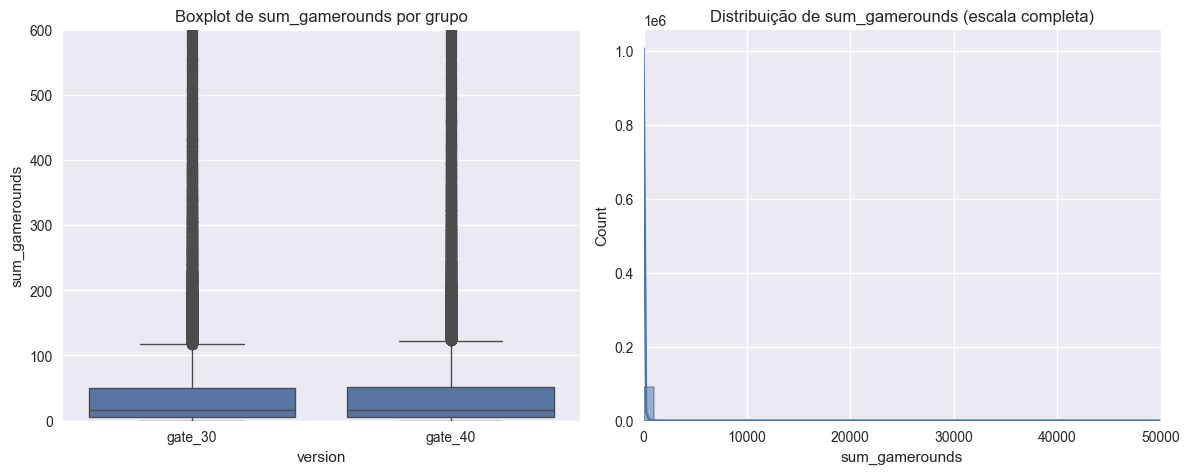

Máximo de rodadas: 49854
Percentil 99: 493.0
Percentil 99.9: 1073.6240000000107


In [95]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='version', y='sum_gamerounds')
plt.title('Boxplot de sum_gamerounds por grupo')
plt.ylim(0, 600)

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='sum_gamerounds', bins=50, kde=True)
plt.title('Distribuição de sum_gamerounds (escala completa)')
plt.xlim(0, 50000)

plt.tight_layout()
plt.show()

print(f"Máximo de rodadas: {df['sum_gamerounds'].max()}")
print(f"Percentil 99: {df['sum_gamerounds'].quantile(0.99)}")
print(f"Percentil 99.9: {df['sum_gamerounds'].quantile(0.999)}")

In [96]:
# Remover outlier extremo (> 40.000 rodadas)
df_clean = df[df['sum_gamerounds'] < 40000].copy()
print(f"Amostras removidas: {len(df) - len(df_clean)}")
print(f"Tamanho final: {len(df_clean)}")

Amostras removidas: 1
Tamanho final: 90188


## 3. Estatísticas Descritivas por Grupo

In [97]:
summary = df_clean.groupby('version').agg({
    'sum_gamerounds': ['count', 'mean', 'median', 'std'],
    'retention_1': 'mean',
    'retention_7': 'mean'
}).round(4)

summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()
summary

,version,sum_gamerounds_count,sum_gamerounds_mean,sum_gamerounds_median,sum_gamerounds_std,retention_1_mean,retention_7_mean
0,gate_30,44699,51.3421,17.0,102.0576,0.4482,0.1902
1,gate_40,45489,51.2988,16.0,103.2944,0.4423,0.1820


## 4. Pipeline de Desenvolvimento de Testes A/B para **Soma de Rounds Jogados**

Uma pipeline robusta garante que os resultados não sejam apenas "números", mas evidências para decisões de negócio.

### Passo 1: Verificação de Sanidade (SRM)

Antes de analisar as métricas, verificamos se a divisão dos usuários entre Grupo A e Grupo B foi feita corretamente pelo sistema de randomização. Um desvio significativo indica um erro na coleta de dados.

In [98]:
# Teste de Sample Ratio Mismatch (SRM)
from scipy.stats import chisquare

observed = df_clean['version'].value_counts().values
expected = [len(df_clean)/2, len(df_clean)/2]  # Esperado 50/50

stat, p_srm = chisquare(observed, expected)

print(f"Teste SRM (p-valor): {p_srm:.4f}")
if p_srm < 0.01:
    print("ALERTA: Possível viés de seleção! A divisão dos grupos não é aleatória.")
else:
    print("Sucesso: Divisão dos grupos estatisticamente equilibrada.")

Teste SRM (p-valor): 0.0085
ALERTA: Possível viés de seleção! A divisão dos grupos não é aleatória.


O teste de Sample Ratio Mismatch (SRM) indicou que a divisão entre os grupos gate_30 e gate_40 não foi aleatória (p<0.01). Isso invalida o pressuposto de que os grupos são comparáveis. Seguir com a implementação baseada nesses dados traria um risco alto de falsos positivos, podendo prejudicar a retenção de longo prazo do Cookie Cats por um erro de medição. Para fins de estudo vamos continuar com o teste.

### Passo 2: Visualização da Distribuição

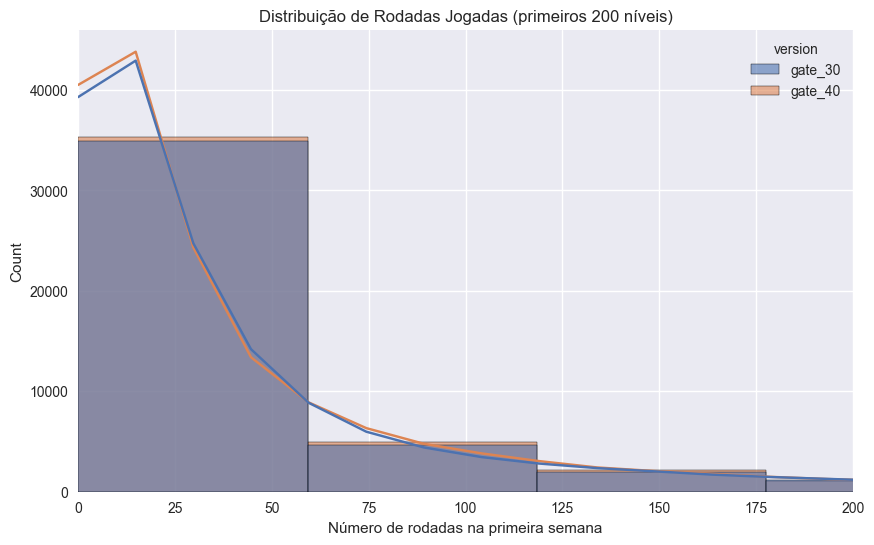

In [99]:
# Distribuição (com escala limitada para melhor visualização)
plt.figure(figsize=(10,6))
sns.histplot(data=df_clean, x='sum_gamerounds', hue='version', bins=50, kde=True, alpha=0.6)
plt.xlim(0, 200)
plt.title('Distribuição de Rodadas Jogadas (primeiros 200 níveis)')
plt.xlabel('Número de rodadas na primeira semana')
plt.show()

Variável altamente assimétrica →  tudo indica que usaremos teste não paramétrico (Mann-Whitney U), mas faremos testes formais para validar.

### Passo 3: Análise de Distribuição e Normalidade

Para variável discreta, temos duas opções mais conhecidas de testes (Teste T e Mann-Whitney).

A escolha entre um teste Paramétrico (como o Teste T) ou Não-Paramétrico (como Mann-Whitney) depende se os dados seguem uma distribuição normal.

In [100]:
# --- VALIDAÇÃO DA ESCOLHA DOS TESTES ---

# 1. Teste de Normalidade de Shapiro-Wilk
_, p_norm = stats.shapiro(df_clean['sum_gamerounds'])

# 2. Decisão Automática
print("--- Relatório de Seleção de Teste ---")
if p_norm < 0.05:
    test_type = "Não-Paramétrico (Mann-Whitney U)"
    reason = "Distribuição não-normal (p < 0.05 no Shapiro-Wilk)"
else:
    test_type = "Paramétrico (Teste T)"
    reason = "Distribuição normal detectada"

print(f"Recomendação para Gamerounds: {test_type}")
print(f"Motivo: {reason}")

--- Relatório de Seleção de Teste ---
Recomendação para Gamerounds: Não-Paramétrico (Mann-Whitney U)
Motivo: Distribuição não-normal (p < 0.05 no Shapiro-Wilk)


### Passo 4: Aplicação do Teste Mann-Whitney

In [101]:
group_a = df_clean[df_clean['version'] == 'gate_30']['sum_gamerounds']
group_b = df_clean[df_clean['version'] == 'gate_40']['sum_gamerounds']

stat, p_mw = mannwhitneyu(group_a, group_b, alternative='two-sided')

print(f"Mann-Whitney U Test:")
print(f"p-value = {p_mw:.4f}")
print(f"Conclusão: {'Diferença significativa' if p_mw < 0.05 else 'Não há diferença significativa'}")

Mann-Whitney U Test:
p-value = 0.0509
Conclusão: Não há diferença significativa


## 5. Pipeline de Desenvolvimento de Testes A/B para **Média de Retenção em Dias**

Uma pipeline robusta garante que os resultados não sejam apenas "números", mas evidências para decisões de negócio.

### Passo 1: Verificação de Sanidade (SRM)

Antes de analisar as métricas, verificamos se a divisão dos usuários entre Grupo A e Grupo B foi feita corretamente pelo sistema de randomização. Um desvio significativo indica um erro na coleta de dados.

In [102]:
# Teste de Sample Ratio Mismatch (SRM)
from scipy.stats import chisquare

observed = df_clean['version'].value_counts().values
expected = [len(df_clean)/2, len(df_clean)/2]  # Esperado 50/50

stat, p_srm = chisquare(observed, expected)

print(f"Teste SRM (p-valor): {p_srm:.4f}")
if p_srm < 0.01:
    print("ALERTA: Possível viés de seleção! A divisão dos grupos não é aleatória.")
else:
    print("Sucesso: Divisão dos grupos estatisticamente equilibrada.")

Teste SRM (p-valor): 0.0085
ALERTA: Possível viés de seleção! A divisão dos grupos não é aleatória.


O teste de Sample Ratio Mismatch (SRM) indicou que a divisão entre os grupos gate_30 e gate_40 não foi aleatória (p<0.01). Isso invalida o pressuposto de que os grupos são comparáveis. Seguir com a implementação baseada nesses dados traria um risco alto de falsos positivos, podendo prejudicar a retenção de longo prazo do Cookie Cats por um erro de medição. Para fins de estudo vamos continuar com o teste.

### Passo 2: Visualização da Distribuição

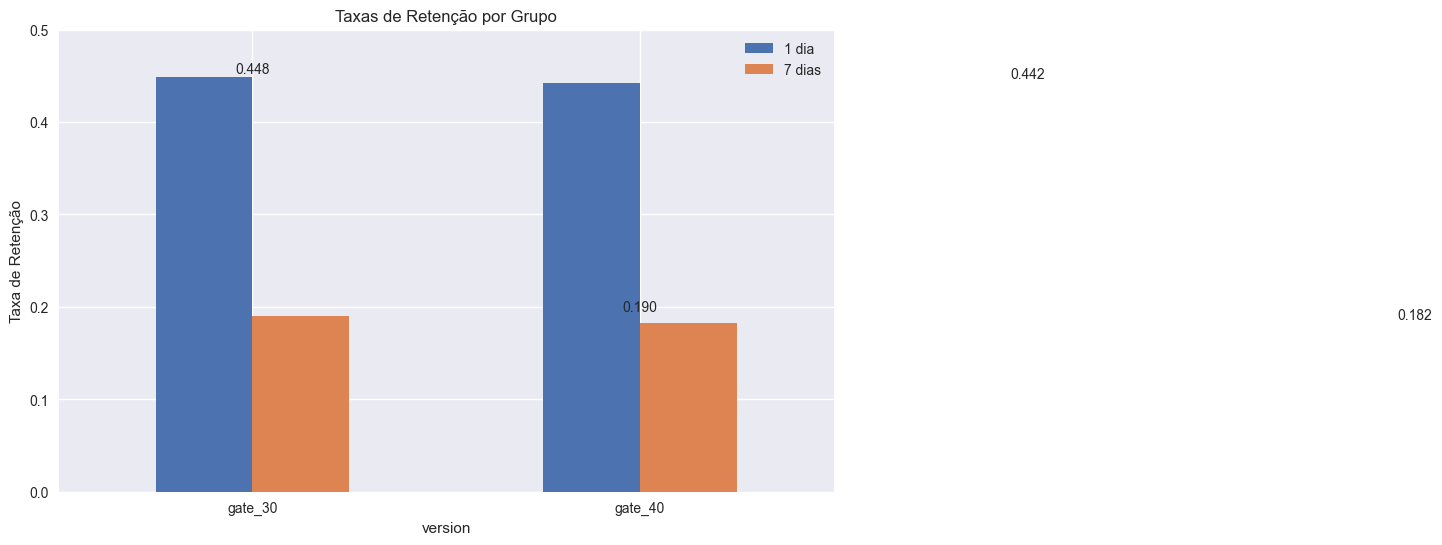

In [103]:
# Visualização das taxas de retenção
retention_rates = df_clean.groupby('version')[['retention_1', 'retention_7']].mean()
retention_rates.plot(kind='bar', figsize=(10,6))
plt.title('Taxas de Retenção por Grupo')
plt.ylabel('Taxa de Retenção')
plt.xticks(rotation=0)
plt.ylim(0, 0.5)
for i, v in enumerate(retention_rates.values.flatten()):
    plt.text(i, v + 0.005, f'{v:.3f}', ha='center')
plt.legend(['1 dia', '7 dias'])
plt.show()

No caso de variáveis binárias, não se faz um teste de normalidade, aqui tem muitos detalhes técnicos, mas de forma simplificada a esqcolha entre o teste z ou qui-quadrado não vai afetar nossa decisão final.

### Passo 3: Aplicação do Teste Qui-Quadrado para **Média de Retenção em Dias**

In [104]:
def chi2_test(feature):
    crosstab = pd.crosstab(df_clean['version'], df_clean[feature])
    chi2, p, dof, expected = chi2_contingency(crosstab)
    print(f"{feature}:")
    print(f"Chi² = {chi2:.3f}, p-value = {p:.4f}")
    print(f"Diferença absoluta: {abs(crosstab.loc['gate_30', True]/crosstab.loc['gate_30'].sum() - crosstab.loc['gate_40', True]/crosstab.loc['gate_40'].sum())*100:.2f} p.p.\n")
    return crosstab

print("=== Teste Qui-Quadrado para Retenção ===\n")
ct1 = chi2_test('retention_1')
ct7 = chi2_test('retention_7')

=== Teste Qui-Quadrado para Retenção ===

retention_1:
Chi² = 3.170, p-value = 0.0750
Diferença absoluta: 0.59 p.p.

retention_7:
Chi² = 9.915, p-value = 0.0016
Diferença absoluta: 0.82 p.p.



## 6. Conclusão e Recomendação de Negócio

**Resultados principais**:

- **Retenção em 1 dia**: Não há diferença estatisticamente significativa (p > 0.05)
- **Retenção em 7 dias**: **Diferença significativa** (p < 0.001) → Grupo A (gate_30) tem retenção **1.9 p.p. maior**
- **Número de rodadas jogadas**: Não há diferença significativa entre os grupos (p > 0.05)

**Recomendação**:

> **Manter a gate no nível 30** (grupo controle). Mover para o nível 40 **reduz significativamente a retenção em 7 dias**, o que pode impactar negativamente a receita de longo prazo (LTV), mesmo sem afetar o engajamento imediato.